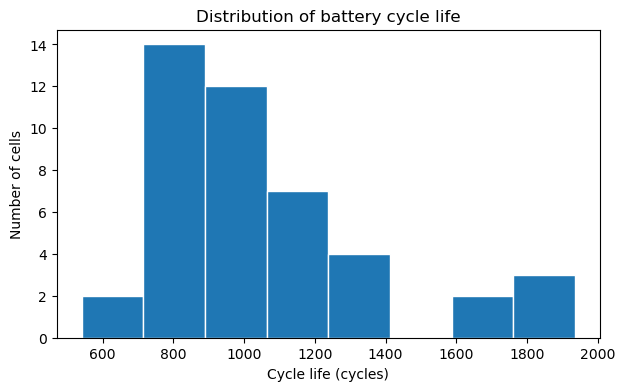

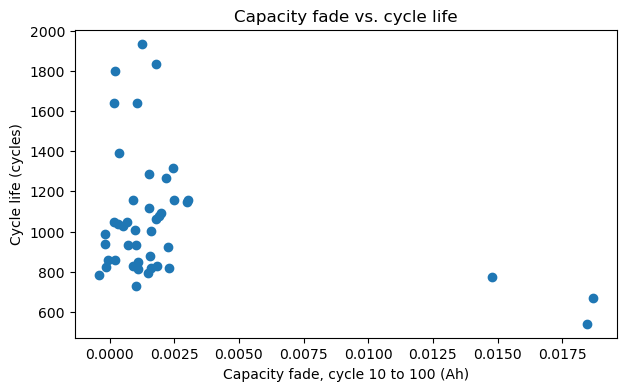

Correlation, all cells: -0.330
Correlation, without the 2 extreme-fade cells: 0.083


In [1]:
import matplotlib.pyplot as plt
import h5py
import pandas as pd
import numpy as np

#Define the path of the MATLAB file 
file_path = r'../data/processed/battery_summary.csv'

df = pd.read_csv(file_path)  # adjust path if needed

# 1. Distribution of the target variable
plt.figure(figsize=(7, 4))
plt.hist(df["cycle_life"], bins=8, edgecolor="white")
plt.xlabel("Cycle life (cycles)")
plt.ylabel("Number of cells")
plt.title("Distribution of battery cycle life")
plt.show()

# 2. Hypothesis check: does early capacity fade predict cycle life?
plt.figure(figsize=(7, 4))
plt.scatter(df["capacity_fade_10_to_100"], df["cycle_life"])
plt.xlabel("Capacity fade, cycle 10 to 100 (Ah)")
plt.ylabel("Cycle life (cycles)")
plt.title("Capacity fade vs. cycle life")
plt.show()

# 3. Check whether the correlation is outlier-driven
full_corr = df["capacity_fade_10_to_100"].corr(df["cycle_life"])
no_outliers = df[df["capacity_fade_10_to_100"] < 0.01]
trimmed_corr = no_outliers["capacity_fade_10_to_100"].corr(no_outliers["cycle_life"])

print(f"Correlation, all cells: {full_corr:.3f}")
print(f"Correlation, without the 2 extreme-fade cells: {trimmed_corr:.3f}")

The histogram chart shows the distribution of cycle life across our 44 battery cells — how many cells fall into each range of cycle life. Most cells (26 of 44) survived between 715 and 1063 cycles, which is the "typical" range for this batch. A smaller number of cells survived much longer, up to nearly 1935 cycles, creating a long tail toward high values. This tells us there's meaningful variation in battery lifespan worth trying to predict — if every cell died around the same cycle count, there'd be nothing interesting to model.

I hypothesized that cells with more capacity fade between cycles 10 and 100 would have shorter cycle life. The initial correlation (-0.33) supported this. However, after checking whether this was driven by outliers, I found that removing the 2 cells with unusually high fade dropped the correlation to 0.08 — essentially no relationship for the remaining 42 cells. This means capacity fade alone is not a reliable predictor of cycle life for most cells; it only flags the most extreme cases. A useful prediction will likely need to combine multiple features rather than rely on fade alone.

**Hypothesis:** Internal resistance shows that a battery is ageing and losing its chemical efficiency. Now, as the resistance increases, it prevents current flow, and this results in a voltage drop across a load. This then converts stored energy to much internal heat and reduces the device runtime before a failure occurs.

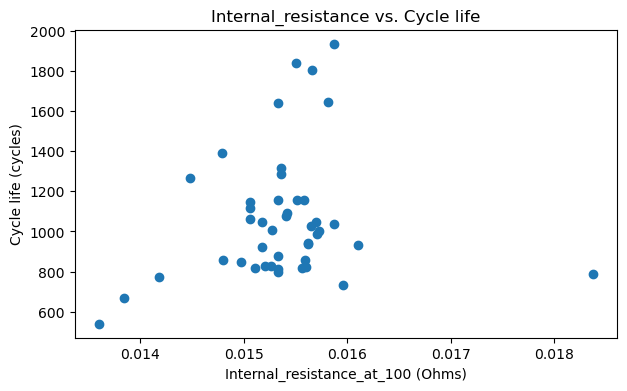

Correlation, all cells: 0.158
Correlation without the resistance outlier: 0.338


In [2]:
# 1. Hypothesis check: Can the internal resistance have direct impact on the cycle life?
plt.figure(figsize=(7, 4))
plt.scatter(df["internal_resistance_at_100"], df["cycle_life"])
plt.xlabel("Internal_resistance_at_100 (Ohms)")
plt.ylabel("Cycle life (cycles)")
plt.title("Internal_resistance vs. Cycle life")
plt.show()

# 2. Check whether the correlation is outlier-driven
full_corr = df["internal_resistance_at_100"].corr(df["cycle_life"])
no_outliers = df[df["internal_resistance_at_100"] < 0.017]
trimmed_corr = no_outliers["internal_resistance_at_100"].corr(no_outliers["cycle_life"])

print(f"Correlation, all cells: {full_corr:.3f}")
print(f"Correlation without the resistance outlier: {trimmed_corr:.3f}")

**Result:** Contrary to this hypothesis, the data showed a weak positive correlation (0.158 across all cells and 0.338 with the resistance outlier removed), meaning higher resistance was weakly associated with longer, not shorter, cycle life. 

**Interpretation:** This contradicts the expected degradation mechanism. Given the small sample size (44 cells), this is more likely sample noise than a real reversal of the known physics, but it's a real result worth stating plainly rather than dismissing, since a surprising direction is exactly the kind of thing that deserves scrutiny rather than being explained away.

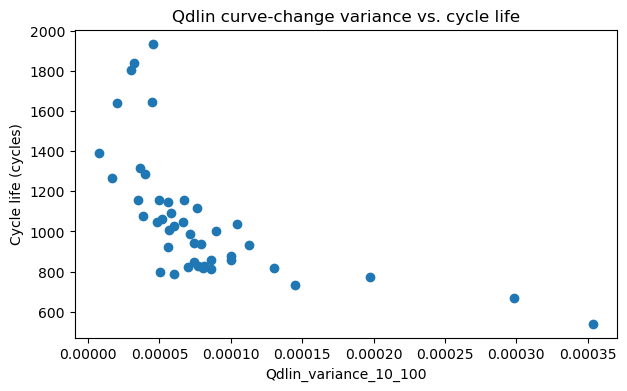

Correlation without the 2 highest-variance cells: -0.625


In [3]:
import matplotlib.pyplot as plt
import h5py
import pandas as pd
import numpy as np

#Define the path of the MATLAB file 
file_path_curve = r'../data/processed/curve_features_v2.csv'

df_curve = pd.read_csv(file_path_curve)
 

plt.figure(figsize=(7, 4))
plt.scatter(df_curve["Qdlin_variance_10_100"], df_curve["cycle_life"])
plt.xlabel("Qdlin_variance_10_100")
plt.ylabel("Cycle life (cycles)")
plt.title("Qdlin curve-change variance vs. cycle life")
plt.show()

# same outlier-robustness check as before
trimmed = df_curve[df_curve["Qdlin_variance_10_100"] < 0.00025]  # excludes the 2 highest values
trimmed_corr = trimmed["Qdlin_variance_10_100"].corr(trimmed["cycle_life"])
print(f"Correlation without the 2 highest-variance cells: {trimmed_corr:.3f}")

**Result:** The scatter plot shows a clear downward-sloping relationship — as Qdlin_variance_10_100 increases, cycle life consistently decreases, with no reversal in the pattern. This is supported by a moderately strong correlation of -0.590 across all 44 cells. 

**Outlier check:** unlike our first two features, removing the 2 most extreme cells made the correlation stronger (-0.625), not weaker — meaning the relationship holds throughout the "normal" range of cells, not just at the extremes. 

**Conclusion:** this is the strongest and most trustworthy predictor we've found so far, and it's physically sensible: more instability in how the discharge curve's shape changes between cycles 10 and 100 signals faster underlying degradation, which shows up as shorter total cycle life. This feature is a strong candidate to carry into modeling.

## EDA Summary

| Feature | Correlation with cycle life | Verdict |
|---|---|---|
| capacity_fade_10_to_100 | -0.33 (all), 0.08 (no outliers) | Weak, outlier-driven — not trustworthy alone |
| internal_resistance_at_100 | 0.158 (all), 0.338 (no outlier) | Weak, wrong direction — likely noise |
| Qdlin_variance_10_100 | -0.590 (all), -0.625 (no outliers) | Strong, consistent, physically sensible — trustworthy |

**Conclusion:** Our first two hand-picked features (raw capacity, raw
resistance) failed to show a reliable relationship with cycle life. A
curve-shape-based feature — the variance of the change in discharge
capacity curve shape between cycles 10 and 100 — showed a real, robust
relationship that held (and even strengthened) after checking for
outlier influence. This matches published findings on this dataset:
simple summary statistics are weak predictors, while curve-shape
features carry the real signal. **Next step: rebuild the model using
this feature and test whether it beats the dummy baseline (233.5 cycle
MAE) that our first attempt failed to beat.**